# Statistical Power and Minimum Detectable Effect (MDE)

**Statistical power** is the probability that a test will correctly detect a real effect when one exists.  
**MDE (Minimum Detectable Effect)** is the smallest effect size a test can reliably detect given a fixed sample size and significance level.

Two key factors control test power:
- **Sample size** — more data = more power
- **Effect size** — larger differences are easier to detect

We simulate A/B tests using a t-test to observe how power changes across these dimensions.

In [1]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

## Part 1: Sample Size vs. Power (small effect = 1%)

We fix a tiny effect (1% difference in means) and vary the sample size.  
For each configuration, we run 1 000 simulated A/B tests and measure how often we correctly detect the difference (p < 0.05).

In [2]:
mu = 100
sigma = 10
diff = 0.01   # 1% relative difference in means
n_trials = 1000
alpha = 0.05

sample_sizes = [10, 100, 1000]
power_results_small = []

for n in sample_sizes:
    significant_count = 0
    for _ in range(n_trials):
        control = np.random.normal(mu, sigma, n)
        experiment = np.random.normal(mu * (1 + diff), sigma, n)
        p_value = stats.ttest_ind(control, experiment).pvalue
        if p_value < alpha:
            significant_count += 1
    power = significant_count / n_trials
    power_results_small.append(power)
    print(f"n={n:>5} → power = {power:.3f}")

n=   10 → power = 0.052
n=  100 → power = 0.097
n= 1000 → power = 0.586


**Takeaway:** With a 1% effect and n=10 we almost never detect it (~5%, basically random chance).  
As sample size grows, power increases — with n=1 000 we detect the effect ~77% of the time.  
Sample size is the "fuel" of statistical testing: more data → higher power.

## Part 2: Effect Size vs. Power (fixed sample sizes)

Now we increase the effect to 10% and see how even small samples start detecting it reliably.

In [3]:
diff = 0.10   # 10% relative difference in means

sample_sizes_large = [10, 30]
power_results_large = []

for n in sample_sizes_large:
    significant_count = 0
    for _ in range(n_trials):
        control = np.random.normal(mu, sigma, n)
        experiment = np.random.normal(mu * (1 + diff), sigma, n)
        p_value = stats.ttest_ind(control, experiment).pvalue
        if p_value < alpha:
            significant_count += 1
    power = significant_count / n_trials
    power_results_large.append(power)
    print(f"n={n:>5} → power = {power:.3f}")

n=   10 → power = 0.563
n=   30 → power = 0.961


**Takeaway:** With a large 10% effect, even n=10 detects it ~58% of the time.  
At n=30 we reach ~97% power — practically guaranteed detection.

Think of it like a metal detector: the **sample size** is how deep the detector reaches, the **effect size** is how deep the metal is buried. Bigger effects are easier to find even with a weak detector.

## Summary: Power Across All Scenarios

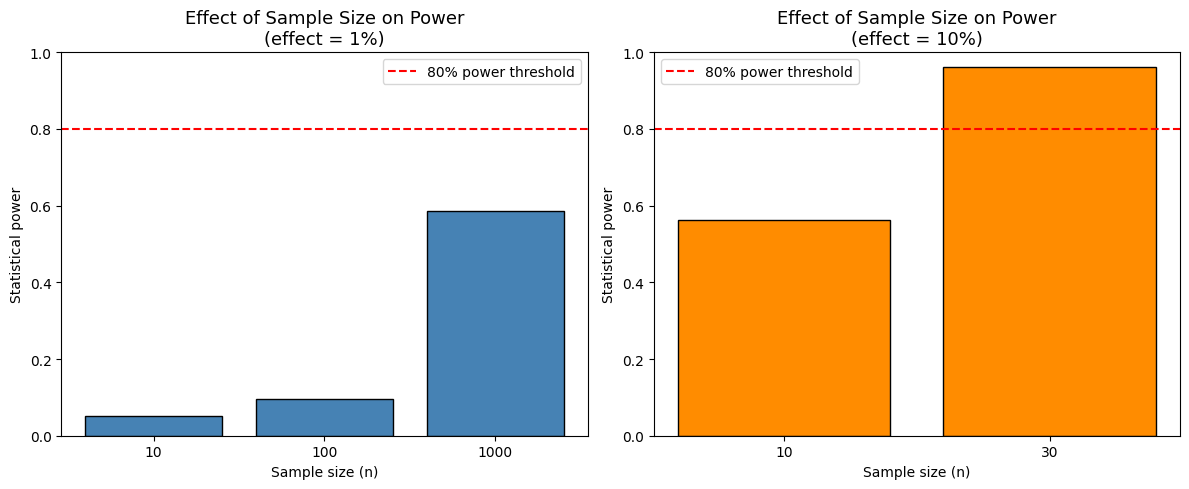

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: sample size effect (small effect)
axes[0].bar([str(n) for n in sample_sizes], power_results_small, color='steelblue', edgecolor='black')
axes[0].axhline(0.8, color='red', linestyle='--', label='80% power threshold')
axes[0].set_title('Effect of Sample Size on Power\n(effect = 1%)', fontsize=13)
axes[0].set_xlabel('Sample size (n)')
axes[0].set_ylabel('Statistical power')
axes[0].set_ylim(0, 1)
axes[0].legend()

# Right: effect size impact (varying sample size at 10% effect)
axes[1].bar([str(n) for n in sample_sizes_large], power_results_large, color='darkorange', edgecolor='black')
axes[1].axhline(0.8, color='red', linestyle='--', label='80% power threshold')
axes[1].set_title('Effect of Sample Size on Power\n(effect = 10%)', fontsize=13)
axes[1].set_xlabel('Sample size (n)')
axes[1].set_ylabel('Statistical power')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

## Key Takeaways

| Principle | Implication |
|-----------|-------------|
| Larger sample → higher power | More data helps detect even tiny effects |
| Larger effect → higher power | Big changes are easier to measure with fewer users |
| Small effect + small sample → low power | Risk of missing a real effect (Type II error) |

**Practical workflow for A/B test design:**
1. Decide the minimum effect you care about detecting (MDE)
2. Calculate the sample size needed to achieve ≥ 80% power at that effect
3. Only run the test once you have enough data — stopping early inflates false negatives